# E12 · The inference frontier: when plain NUTS is not enough (or is too slow)

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | S&P 500 daily log-returns, 1 July - 26 December 2008: 125 trading days through the Lehman collapse (`sp500`, via pymc-examples) |
| **You will learn** | Building a trustworthy **reference posterior** and scoring every other method against it · a posterior where neither the centred nor the non-centred form is clean · nutpie's **low-rank mass matrix** and **normalizing-flow adaptation** (`adaptation="flow"`) and what they really cost · Laplace, mean-field / full-rank ADVI and **Pathfinder** · the **Pareto $\hat k$** diagnostic for "can I trust this approximation?" when there is no reference · what a too-narrow posterior does to a risk number · Pathfinder as an initialiser for NUTS |

The subject of this notebook is not a model, it is the **inference algorithm**. E02 taught
the standard reflex: *funnel, therefore non-centre*. Challenge C07 then met a model where
that reflex trades one problem for another. Here we take that model - a latent
log-volatility random walk - and run the whole modern toolbox over it, from the default
sampler to a sampler that *learns a change of variables with a neural network during
warm-up*, and then down to the approximations people reach for when MCMC is too slow.

Everything is scored against one carefully built reference posterior, so the claims are
checkable. Two warnings before we start:

- This is a frontier topic and the honest answer is often "the fancy method works and you
  do not need it". We report what we measured, including when the clever tool loses.
- nutpie's flow adaptation is marked *experimental* and needs the JAX stack (`jax`,
  `flowjax`, `equinox`, `optax` - all installed here). Its API may change.

**Where the time goes.** The model is deliberately small (129 parameters), so every NUTS
fit takes seconds. The single exception is the normalizing-flow run in section 3, which
takes longer than everything else in the notebook put together; the last cell prints the
measured split.

In [1]:
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import nutpie
import pandas as pd
import pymc as pm
import pymc_extras as pmx
import pytensor
import pytensor.tensor as pt
import xarray as xr
from pymc.pytensorf import join_nonshared_inputs
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 2008
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
warnings.filterwarnings("ignore", category=FutureWarning)
NOTEBOOK_START = time.perf_counter()
section_seconds = {}

print(f"PyMC {pm.__version__}, nutpie {nutpie.__version__}, pymc-extras {pmx.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, nutpie 0.16.11, pymc-extras 0.15.1, ArviZ 1.3.0


## 1 · A posterior that is awkward in *both* parameterisations

The data: daily returns of the S&P 500 in percent. We use only the second half of 2008
- 125 trading days - because this notebook fits the same model about twenty times. C07 uses
800 days of the same series and meets the same two sampling problems there; the short
window is for the runtime.

In [2]:
data.describe("sp500")
sp500 = data.load("sp500")
window = sp500.loc["2008-07-01":"2008-12-26"]
returns = 100 * window["change"].values
dates = window.index
T = len(returns)
print(f"\n{T} trading days, {dates[0].date()} to {dates[-1].date()}; "
      f"daily sd {returns[:50].std():.1f}% in the first 50 days, {returns[50:100].std():.1f}% in the next 50")

sp500: Daily close and log-return ('change').
  source: S&P 500 index daily closes (2008-2019), via pymc-examples.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/SP500.csv

125 trading days, 2008-07-01 to 2008-12-26; daily sd 1.4% in the first 50 days, 4.4% in the next 50


The model is the stochastic-volatility model of C07: Student-t returns whose log-scale
follows a random walk,

$$
r_t \sim \text{StudentT}(\nu,\ \mu,\ e^{v_t}), \qquad v_t = v_{t-1} + \sigma_v\,\epsilon_t, \qquad
\epsilon_t \sim \text{Normal}(0, 1),
$$

with $\sigma_v \sim \text{HalfNormal}(0.2)$ (volatility changes by some percent per day, not
by multiples), $\nu \sim \text{Gamma}(2, 0.1)$ and $\mu \sim \text{Normal}(0, 0.5)$. It can be
written two ways, exactly like the county effects in E02:

- **centred**: sample the path $v_t$ directly (`pm.GaussianRandomWalk`);
- **non-centred**: sample the standardised shocks $\epsilon_t$ and build
  $v_t = v_0 + \sigma_v \sum_{s \le t} \epsilon_s$.

E02's rule of thumb was *centred when a group's own data dominate, non-centred when the
prior dominates*, and its uncomfortable footnote was that a real hierarchy contains both
kinds of group at once (counties with 1 home and with 100; NBA players with 1 play and
with 600). This model has the same split, but inside one latent vector where you cannot
separate the two kinds by hand:

- each daily **step** $v_t - v_{t-1}$ is informed by a single noisy return: prior-dominated,
  wants to be non-centred;
- the **level** $v_t$ is informed by weeks of neighbouring returns: data-dominated, wants to
  be centred.

In [3]:
def sv_model(centred):
    with pm.Model(coords={"date": dates}) as model:
        vol_of_vol = pm.HalfNormal("vol_of_vol", 0.2)  # sigma_v
        nu = pm.Gamma("nu", 2, 0.1)
        mu = pm.Normal("mu", 0, 0.5)
        if centred:
            log_vol = pm.GaussianRandomWalk("log_vol", sigma=vol_of_vol, init_dist=pm.Normal.dist(0, 1), dims="date")
        else:
            log_vol_0 = pm.Normal("log_vol_0", 0, 1)
            z = pm.Normal("z", 0, 1, dims="date")
            log_vol = pm.Deterministic("log_vol", log_vol_0 + pt.cumsum(vol_of_vol * z), dims="date")
        pm.StudentT("ret", nu=nu, mu=mu, sigma=pm.math.exp(log_vol), observed=returns, dims="date")
    return model


centred_model, noncentred_model = sv_model(centred=True), sv_model(centred=False)

### A sampler harness that keeps the books

Timing claims are the point of this notebook, so we call nutpie directly instead of going
through `pm.sample`: that lets us time **compilation**, **warm-up** and **sampling**
separately (a progress callback notes the moment the last chain leaves warm-up) and count
**gradient evaluations**, a cost measure that does not depend on what else the laptop is
doing. The `pm.sample` spelling of each run is given in the table of section 5.

Every run uses 4 chains, 1000 warm-up and 1000 kept draws unless stated. The yardstick is
the bulk ESS of $\sigma_v$ (`vol_of_vol`) - it is the slowest-mixing quantity in every run
below - per second and per 1000 gradients, *including* compilation and warm-up.

In [4]:
ladder = {}  # label -> dict of measurements
fits = {}    # label -> DataTree


def run_nuts(model, label, *, adaptation="diag", jax_backend=False, flow_settings=None,
             draws=1000, tune=1000, record=True, **sampler_kwargs):
    start = time.perf_counter()
    if jax_backend:
        compiled = nutpie.compile_pymc_model(model, backend="jax", gradient_backend="jax")
    else:
        compiled = nutpie.compile_pymc_model(model)  # numba
    if flow_settings is not None:
        compiled = compiled.with_transform_adapt(**flow_settings)
    compiled_at = time.perf_counter()

    # Time each chain by its own clock (nutpie reports a per-chain runtime), so that the split
    # into warm-up and sampling means the same thing whether chains run side by side or in turn.
    warm_ms, total_ms = {}, {}

    def note_chain_clocks(chains):
        for i, c in enumerate(chains):
            if c.started:
                total_ms[i] = c.runtime_ms
                if not c.tuning and i not in warm_ms:
                    warm_ms[i] = c.runtime_ms

    idata = nutpie.sample(compiled, draws=draws, tune=tune, chains=4, seed=RANDOM_SEED, adaptation=adaptation,
                          progress_bar=False, progress_callback=note_chain_clocks, progress_rate=50, **sampler_kwargs)
    done = time.perf_counter()

    grads_warmup = int(idata.warmup_sample_stats["n_steps"].sum())
    grads_sampling = int(idata.sample_stats["n_steps"].sum())
    if len(warm_ms) == 4:
        warm_s = np.mean([warm_ms[i] for i in range(4)]) / 1000
        sampling_s = np.mean([total_ms[i] - warm_ms[i] for i in range(4)]) / 1000
    else:  # the run was too quick for the callback: split the wall time by gradient share
        warm_s = (done - compiled_at) * grads_warmup / (grads_warmup + grads_sampling)
        sampling_s = (done - compiled_at) - warm_s
    scale = az.summary(idata, var_names=["vol_of_vol"])
    path = az.summary(idata, var_names=["log_vol"])
    row = {
        "divergences": int(idata.sample_stats["diverging"].sum()),
        "max r_hat": max(scale["r_hat"].iloc[0], path["r_hat"].max()),
        "ESS sigma_v": scale["ess_bulk"].iloc[0],
        "min ESS log_vol": path["ess_bulk"].min(),
        "grads/draw": grads_sampling / (4 * draws),
        "compile s": compiled_at - start, "warm-up s": warm_s, "sampling s": sampling_s,  # per chain
        "total s": done - start,  # wall clock
        "microsec/grad": 1e6 * sampling_s / (grads_sampling / 4),  # per chain, sampling phase only
        "ESS/s": scale["ess_bulk"].iloc[0] / (done - start),
        "ESS/1000 grads": 1000 * scale["ess_bulk"].iloc[0] / (grads_warmup + grads_sampling),
    }
    if record:
        ladder[label], fits[label] = row, idata
    print(f"{label}: {row['divergences']} divergences, ESS(sigma_v) {row['ESS sigma_v']:.0f}, {row['total s']:.1f} s")
    return idata, row

### The reference posterior

Before comparing anything we need a posterior we trust. The recipe: take the
parameterisation with the better ESS, remove its divergences with a very small step size
(`target_accept=0.99`), run four times longer than usual - and then **cross-check against
the other parameterisation**, run long. The two forms fail in different ways (next
section), so if they agree, neither failure is biasing the answer.

In [5]:
tic = time.perf_counter()
reference, ref_row = run_nuts(noncentred_model, "reference (non-centred, 0.99)", draws=4000, tune=2000,
                              target_accept=0.99, record=False)
crosscheck, cross_row = run_nuts(centred_model, "cross-check (centred, long)", draws=6000, tune=2000,
                                 target_accept=0.9, record=False)
section_seconds["1 reference + cross-check"] = time.perf_counter() - tic

last_day = dates[-1]
rows = {}
for name, idata in [("reference", reference), ("cross-check", crosscheck)]:
    post = idata.posterior
    s = az.summary(idata, var_names=["vol_of_vol", "nu"], round_to=4)
    rows[name] = {
        "divergences": int(idata.sample_stats["diverging"].sum()),
        "sigma_v mean": s.loc["vol_of_vol", "mean"], "sigma_v sd": s.loc["vol_of_vol", "sd"],
        "sigma_v mcse": s.loc["vol_of_vol", "mcse_mean"], "sigma_v ESS": s.loc["vol_of_vol", "ess_bulk"],
        "nu mean": s.loc["nu", "mean"],
        "last-day log_vol mean": float(post["log_vol"].sel(date=last_day).mean()),
        "last-day log_vol sd": float(post["log_vol"].sel(date=last_day).std()),
    }
pd.DataFrame(rows).T.round(4)

reference (non-centred, 0.99): 0 divergences, ESS(sigma_v) 5342, 6.6 s


cross-check (centred, long): 0 divergences, ESS(sigma_v) 658, 7.8 s


,divergences,sigma_v mean,sigma_v sd,sigma_v mcse,sigma_v ESS,nu mean,last-day log_vol mean,last-day log_vol sd
reference,0.0,0.1207,0.0348,0.0005,5342.1586,26.6214,0.6546,0.3838
cross-check,0.0,0.1211,0.0345,0.0013,657.8739,26.6006,0.6580,0.3875


No divergences in either run, and the two parameterisations agree on $\sigma_v$ to within
one Monte Carlo standard error of the noisier run (`sigma_v mcse`) and on everything else
to about 1% of a posterior sd. The reference has several thousand effective draws even for
$\sigma_v$ and cost a few seconds - on a model this size a gold standard is cheap, which
is exactly why we chose it. From here on, `reference` is the truth.

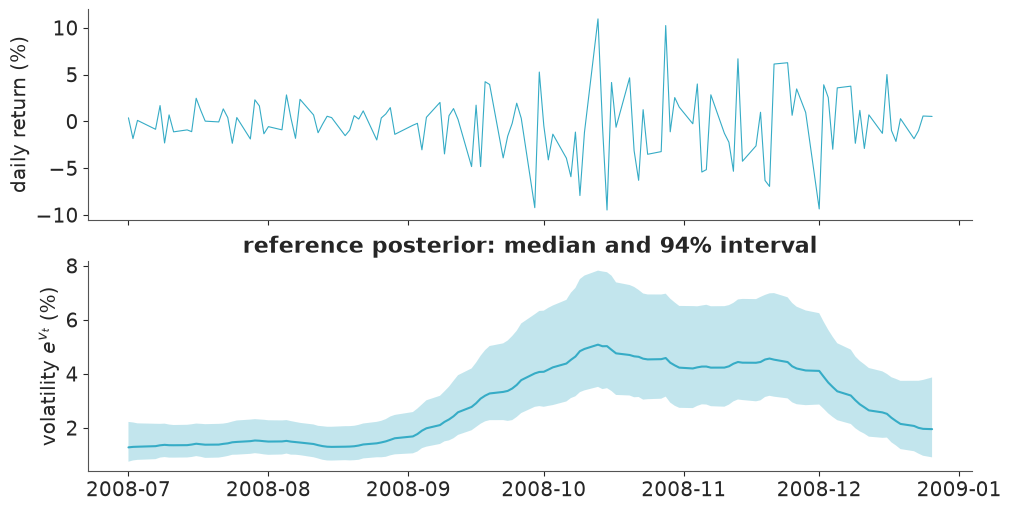

In [6]:
ref_post = reference.posterior
ref_vol = np.exp(ref_post["log_vol"])
lo, mid, hi = ref_vol.quantile([0.03, 0.5, 0.97], dim=("chain", "draw")).values

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(dates, returns, lw=0.8)
axes[0].set(ylabel="daily return (%)")
axes[1].fill_between(dates, lo, hi, alpha=0.3)
axes[1].plot(dates, mid)
axes[1].set(ylabel="volatility $e^{v_t}$ (%)", title="reference posterior: median and 94% interval");

Volatility roughly quadruples between August and mid-October 2008 (from about 1.3% to about
5% a day) and has come most of the way back down, to about 2%, by the end of December.
The band is wide: one return a day does not pin down that day's volatility.

## 2 · The ladder, rungs 1-3: what reparameterisation can and cannot do

Default nutpie NUTS (diagonal mass matrix, `target_accept=0.8`) on both forms, plus the fix
C07 settled on: non-centred with a smaller step size.

In [7]:
tic = time.perf_counter()
run_nuts(centred_model, "centred")
run_nuts(noncentred_model, "non-centred")
run_nuts(noncentred_model, "non-centred, target_accept 0.95", target_accept=0.95)
section_seconds["2 plain NUTS rungs"] = time.perf_counter() - tic

def ladder_so_far():
    cols = {"divergences": 0, "max r_hat": 3, "ESS sigma_v": 0, "min ESS log_vol": 0, "grads/draw": 1, "total s": 1}
    return pd.DataFrame(ladder).T[list(cols)].round(cols)


ladder_so_far()

centred: 0 divergences, ESS(sigma_v) 97, 2.5 s


non-centred: 59 divergences, ESS(sigma_v) 985, 1.3 s


non-centred, target_accept 0.95: 2 divergences, ESS(sigma_v) 1241, 1.7 s


,divergences,max r_hat,ESS sigma_v,min ESS log_vol,grads/draw,total s
centred,0.0,1.021,97.0,607.0,56.5,2.5
non-centred,59.0,1.004,985.0,1029.0,39.2,1.3
"non-centred, target_accept 0.95",2.0,1.003,1241.0,1806.0,63.0,1.7


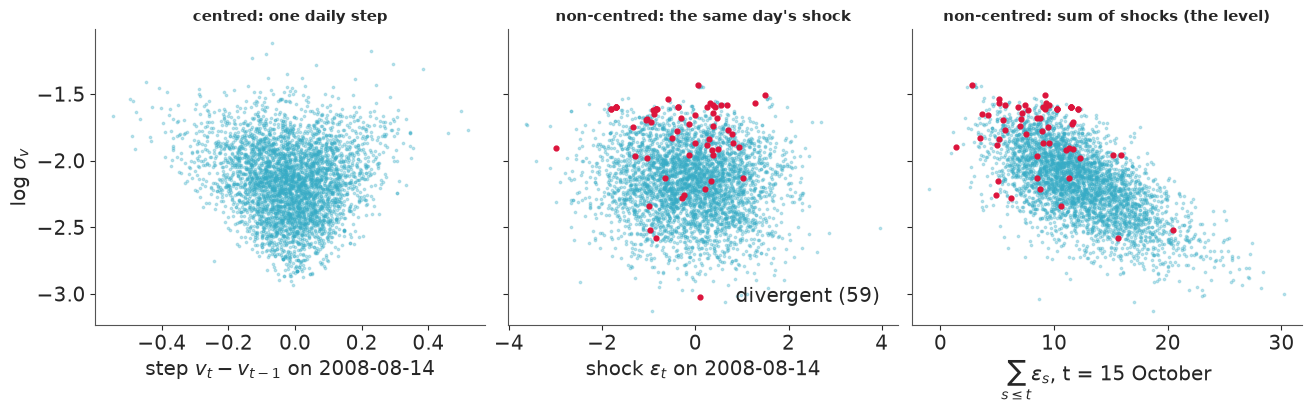

In [8]:
def scale_vs_step(idata, centred, day):
    """log sigma_v against the step of the log-vol path on `day`, in the coordinates the sampler moves in."""
    post = idata.posterior
    i = dates.get_loc(day)
    log_scale = np.log(post["vol_of_vol"].values.ravel())
    if centred:
        step = (post["log_vol"].isel(date=i) - post["log_vol"].isel(date=i - 1)).values.ravel()
    else:
        step = post["z"].isel(date=i).values.ravel()
    return step, log_scale


quiet_day = pd.Timestamp("2008-08-14")
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
step, log_scale = scale_vs_step(fits["centred"], True, quiet_day)
axes[0].scatter(step, log_scale, s=3, alpha=0.3)
axes[0].set(xlabel=f"step $v_t - v_{{t-1}}$ on {quiet_day.date()}", ylabel="log $\\sigma_v$")
axes[0].set_title("centred: one daily step", fontsize=11)

div = fits["non-centred"].sample_stats["diverging"].values.ravel()
step, log_scale = scale_vs_step(fits["non-centred"], False, quiet_day)
axes[1].scatter(step[~div], log_scale[~div], s=3, alpha=0.3)
axes[1].scatter(step[div], log_scale[div], s=12, color="crimson", label=f"divergent ({div.sum()})")
axes[1].set(xlabel=f"shock $\\epsilon_t$ on {quiet_day.date()}")
axes[1].set_title("non-centred: the same day's shock", fontsize=11)
axes[1].legend(loc="lower right")

# the level of the path on a given day is sigma_v times the SUM of all shocks up to that day
z_sum = fits["non-centred"].posterior["z"].sel(date=slice(None, "2008-10-15")).sum("date").values.ravel()
axes[2].scatter(z_sum[~div], log_scale[~div], s=3, alpha=0.3)
axes[2].scatter(z_sum[div], log_scale[div], s=12, color="crimson")
axes[2].set(xlabel="$\\sum_{s \\leq t} \\epsilon_s$, t = 15 October")
axes[2].set_title("non-centred: sum of shocks (the level)", fontsize=11);

Three pictures of one posterior, and the whole dilemma:

- **Left, centred.** A single day's step is barely informed by its one return, so its width
  simply follows $\sigma_v$: E02's funnel, 124 times over. The neck is never reached -
  $\sigma_v$ is bounded away from zero by the data - so there are **no divergences**, and
  that is the trap: the table shows an ESS for $\sigma_v$ of roughly a hundred out of 4000
  draws and an `r_hat` of 1.02. To move $\sigma_v$ the sampler must rescale all 124 steps
  at once, and it can only do that slowly.
- **Middle, non-centred.** The individual shocks are now independent of $\sigma_v$. Fixed.
- **Right, non-centred.** But the *level* of volatility in mid-October is a sum of 75
  shocks times $\sigma_v$, and the data know that level well. So the sum is tied to
  $\sigma_v$ along a curved ridge (the product is what is determined), and that is where
  the step size tuned on the bulk fails: **dozens of divergences**, concentrated at large
  $\sigma_v$.

A smaller step size (`target_accept=0.95`) takes the non-centred run from dozens of
divergences to a couple, for about 1.6 times the gradient evaluations per draw (the
reference used 0.99 to get to zero). That is a perfectly good practical answer - remember
it, because everything that follows has to beat it.

## 3 · Rungs 4-7: teaching the sampler the geometry

### Low-rank mass matrix

NUTS works best when the posterior looks like a round standard Normal. The **mass matrix**
is a linear change of variables towards that ideal. The default is *diagonal* - it rescales
each coordinate but cannot rotate. nutpie's `adaptation="low_rank"` adds a handful of
learned directions on top of the diagonal, which is enough to undo strong **linear**
correlations while keeping each leapfrog step cheap. A random walk is full of those: neighbouring $v_t$ are
nearly collinear. What a linear map cannot do, by definition, is straighten a funnel,
whose width changes with position.

In [9]:
tic = time.perf_counter()
run_nuts(centred_model, "centred, low-rank", adaptation="low_rank")
run_nuts(noncentred_model, "non-centred, low-rank", adaptation="low_rank")
section_seconds["3a low-rank rungs"] = time.perf_counter() - tic

ladder_so_far()

centred, low-rank: 0 divergences, ESS(sigma_v) 96, 2.6 s


non-centred, low-rank: 8 divergences, ESS(sigma_v) 1368, 4.0 s


,divergences,max r_hat,ESS sigma_v,min ESS log_vol,grads/draw,total s
centred,0.0,1.021,97.0,607.0,56.5,2.5
non-centred,59.0,1.004,985.0,1029.0,39.2,1.3
"non-centred, target_accept 0.95",2.0,1.003,1241.0,1806.0,63.0,1.7
"centred, low-rank",0.0,1.035,96.0,564.0,12.2,2.6
"non-centred, low-rank",8.0,1.005,1368.0,3383.0,13.9,4.0


Exactly the prediction. On the **centred** model the low-rank metric makes every draw
several times cheaper (`grads/draw`) because the collinear path no longer forces tiny
steps - and leaves the ESS of $\sigma_v$ where it was, because the funnel is not a linear
feature. On the **non-centred** model it removes most of the correlation between shocks
that the likelihood induced: a third of the gradients per draw, more effective draws, and
most of the divergences gone - though not all: the curved ridge is still there. The
adaptation is not free: estimating the extra directions makes warm-up several times
longer in wall time (see the cost table below), which on a model this fast is visible.

### Normalizing-flow adaptation

The idea behind nutpie's `adaptation="flow"` (Seyboldt and co-authors; experimental) takes
the mass-matrix logic one step further. If a linear change of variables helps, learn a
**non-linear** one:

1. Run NUTS for a while with an ordinary mass matrix and keep the warm-up draws *and
   their gradients*.
2. Fit an invertible neural network $f$ (a normalizing flow built from coupling layers) so
   that the posterior, seen through $f^{-1}$, is as close to a standard Normal as possible.
   The loss is a Fisher divergence: it compares the *gradients* of the transformed
   log-density with those of a standard Normal, which is why the gradients were kept and
   why no density needs to be normalised.
3. Run NUTS in the transformed coordinates, collect better draws, refit $f$, repeat until
   warm-up ends. Then freeze $f$ and sample.

In other words, the sampler *discovers a reparameterisation* instead of you writing one.
If it works it should rescue the centred model - the one we could not fix above.

The price list, before the results: the model must be compiled to JAX with JAX gradients
(`backend="jax", gradient_backend="jax"` - with the default numba backend sampling dies
with `RuntimeError: All initialization points failed`); each chain trains its own network
several times during warm-up; and every leapfrog step afterwards goes through that network.
To separate the cost of "JAX" from the cost of "flow" we first run the plain centred model
on the JAX backend.

The flow settings are passed with `with_transform_adapt`. nutpie's defaults (8 coupling
layers, up to 200 epochs per refit) took about six minutes on a model of similar size when
we tried them (E02's radon model with varying slopes); four layers and 60 epochs were
enough here.

In [10]:
tic = time.perf_counter()
run_nuts(centred_model, "centred, JAX backend", jax_backend=True)
section_seconds["3b JAX-backend rung"] = time.perf_counter() - tic

tic = time.perf_counter()
FLOW_SETTINGS = dict(num_layers=4, max_epochs=60, debug_save_bijection=True)  # the last one only for the picture below
# cores=1: each chain trains its own flow in JAX. Measured peak memory of this notebook was over
# 3.4 GB with four flows training at once, about 3 GB with two, and 2.4 GB one at a time. Running
# them in turn keeps all four chains and every per-gradient number; only this rung's wall-clock
# time suffers (so read its "total s" as an upper bound on what a bigger machine would need).
flow_idata, flow_row = run_nuts(centred_model, "centred, flow", adaptation="flow", jax_backend=True,
                                flow_settings=FLOW_SETTINGS, store_unconstrained=True, cores=1)
section_seconds["3c normalizing-flow rung"] = time.perf_counter() - tic

centred, JAX backend: 0 divergences, ESS(sigma_v) 147, 22.2 s


centred, flow: 0 divergences, ESS(sigma_v) 747, 191.0 s


### What did the flow learn?

`debug_save_bijection=True` is a debugging switch, not public API: it makes nutpie keep
every flow it fits in a module-level list. We take the last one (fitted by one of the
chains near the end of warm-up) and use it in both directions: pull the posterior draws
back through $f^{-1}$ into the space NUTS actually moved in, and push standard-Normal noise
forward through $f$ to see the flow's own idea of the posterior. The flow mixes
coordinates, so "the same day's step" in the transformed space is only loosely the same
quantity - the point is whether the dependence on the scale coordinate is gone.

   original space: sd of daily steps, scale coordinate in its top fifth / bottom fifth = 2.15
transformed space: sd of daily steps, scale coordinate in its top fifth / bottom fifth = 0.98


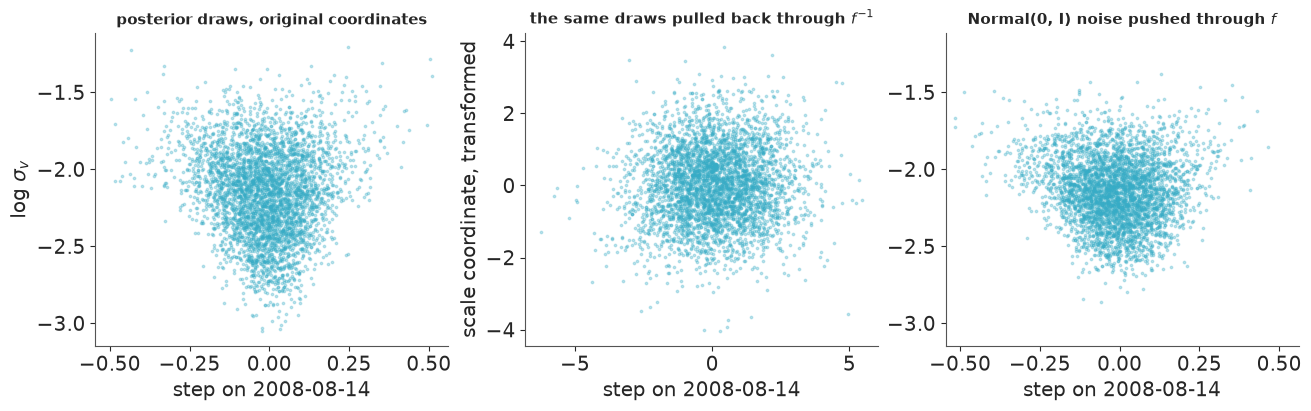

In [11]:
import jax
import jax.numpy as jnp
from nutpie import transform_adapter

_, bijection, _ = transform_adapter._BIJECTION_TRACE[-1]

x = flow_idata.sample_stats["unconstrained_draw"].values.reshape(-1, T + 3)  # nutpie's flat unconstrained vector
# locate the coordinates we want to plot by matching them against the named draws
first = flow_idata.posterior.isel(chain=0, draw=0)
col_scale = int(np.argmin(np.abs(x[0] - np.log(float(first["vol_of_vol"])))))
col_path = int(np.argmin(np.abs(x[0] - float(first["log_vol"].isel(date=0)))))
assert np.allclose(x[:, col_path:col_path + T], flow_idata.posterior["log_vol"].values.reshape(-1, T))

z_space = np.asarray(jax.vmap(bijection.inverse)(jnp.asarray(x)))
pushed = np.asarray(jax.vmap(bijection.transform)(jnp.asarray(rng.normal(size=x.shape))))

i = col_path + dates.get_loc(quiet_day)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, pts, title in [
    (axes[0], x, "posterior draws, original coordinates"),
    (axes[1], z_space, "the same draws pulled back through $f^{-1}$"),
    (axes[2], pushed, "Normal(0, I) noise pushed through $f$"),
]:
    ax.scatter(pts[:, i] - pts[:, i - 1], pts[:, col_scale], s=3, alpha=0.3)
    ax.set(xlabel=f"step on {quiet_day.date()}")
    ax.set_title(title, fontsize=11)
axes[0].set(ylabel="log $\\sigma_v$")
axes[1].set(ylabel="scale coordinate, transformed")
axes[2].set(xlim=axes[0].get_xlim(), ylim=axes[0].get_ylim())

for name, pts in [("original", x), ("transformed", z_space)]:
    steps = np.diff(pts[:, col_path:col_path + T], axis=1)
    low, high = np.quantile(pts[:, col_scale], [0.2, 0.8])
    lo_sd, hi_sd = steps[pts[:, col_scale] < low].std(), steps[pts[:, col_scale] > high].std()
    print(f"{name:>11} space: sd of daily steps, scale coordinate in its top fifth / bottom fifth = {hi_sd / lo_sd:.2f}")

In [12]:
# The JAX part of the notebook is over: drop the saved bijections and XLA's compiled programs
# (several hundred MB) before the approximate-inference sections, which do not use JAX.
import gc

transform_adapter._BIJECTION_TRACE.clear()
del bijection
jax.clear_caches()
gc.collect();

Left: the funnel, as before. Middle: the same draws in the coordinates NUTS was given after
warm-up - a featureless blob. Right: what comes out when plain Gaussian noise is pushed
through the network - a recognisable, if blunter, funnel: the network has learned the
shape. (Which chain's flow ends up last in the list varies from run to run, so the middle
and right panels change a little between runs.) The printed ratio makes the same point for all 124 steps at once: in the
original coordinates the steps are about twice as spread out when $\sigma_v$ is in its top
fifth as when it is in its bottom fifth; in the transformed coordinates the ratio is
about one.

### The scoreboard

Correctness first. For every run: the posterior mean of $\sigma_v$ as a **standardised
error** $(\text{mean} - \text{mean}_\text{ref}) / \text{sd}_\text{ref}$, the **ratio of posterior sds**,
the Wasserstein-1 distance to the reference for $\sigma_v$ in units of the reference sd
(`az.wasserstein`), and the same two summaries over the 125 daily log-volatilities
(median absolute standardised error, median sd ratio).

In [13]:
ref_draws = {v: ref_post[v].values.reshape(-1, *ref_post[v].shape[2:]) for v in ["vol_of_vol", "nu", "mu", "log_vol"]}
ref_mean = {v: d.mean(0) for v, d in ref_draws.items()}
ref_sd = {v: d.std(0) for v, d in ref_draws.items()}


def as_draws(idata):
    post = idata.posterior
    return {v: post[v].values.reshape(-1, *post[v].shape[2:]) for v in ["vol_of_vol", "nu", "mu", "log_vol"]}


def accuracy(draws, weights=None):
    """Standardised error of the mean and sd ratio against the reference, optionally importance-weighted."""
    w = np.full(len(draws["vol_of_vol"]), 1.0) if weights is None else np.asarray(weights)
    w = w / w.sum()
    out = {}
    for v, label in [("vol_of_vol", "sigma_v"), ("log_vol", "log_vol")]:
        d = draws[v].reshape(len(w), -1)
        mean = w @ d
        sd = np.sqrt(w @ (d - mean) ** 2)
        z, ratio = (mean - ref_mean[v]) / ref_sd[v], sd / ref_sd[v]
        if v == "vol_of_vol":
            out["sigma_v mean"], out["sigma_v z"], out["sigma_v sd ratio"] = float(mean[0]), float(z[0]), float(ratio[0])
        else:
            out["log_vol median |z|"], out["log_vol sd ratio"] = float(np.median(np.abs(z))), float(np.median(ratio))
    return out


def w1_to_reference(idata):
    n = min(2000, idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"])
    w1 = az.wasserstein(idata, reference, var_names=["vol_of_vol"], joint=False, num_samples=n, round_to="none")
    return float(w1) / float(ref_sd["vol_of_vol"])


score = pd.DataFrame({k: {**accuracy(as_draws(f)), "sigma_v W1/sd": w1_to_reference(f)} for k, f in fits.items()}).T
score.round(3)

,sigma_v mean,sigma_v z,sigma_v sd ratio,log_vol median |z|,log_vol sd ratio,sigma_v W1/sd
centred,0.121,0.003,0.981,0.009,0.999,0.048
non-centred,0.120,-0.008,0.947,0.010,0.997,0.047
"non-centred, target_accept 0.95",0.118,-0.065,0.977,0.019,0.998,0.094
"centred, low-rank",0.116,-0.128,0.950,0.015,0.978,0.145
"non-centred, low-rank",0.121,-0.000,0.978,0.009,0.999,0.062
"centred, JAX backend",0.123,0.068,1.000,0.019,1.014,0.048
"centred, flow",0.121,0.008,1.006,0.009,0.995,0.035


Read this table with the Monte Carlo error in mind: a run with an ESS of 100 for $\sigma_v$
has a standardised error of the mean of about $\pm 1/\sqrt{100} = 0.1$ from noise alone.
Against that yardstick **no run is detectably biased**: even the badly mixing centred
fits land within their own noise of the reference, sd ratios are within 5% of one, the
Wasserstein distances are a small fraction of a posterior sd, and the daily volatilities
agree everywhere. The difference between the rungs is not what answer they give but how
much you can trust it and what it cost - the next table. (With an ESS of a hundred and an
`r_hat` of 1.02-1.04 you would not *know* the centred answer was fine without the others.)

In [14]:
cost_cols = ["divergences", "max r_hat", "ESS sigma_v", "grads/draw", "microsec/grad", "compile s", "warm-up s",
             "sampling s", "ESS/s", "ESS/1000 grads"]
cost = pd.DataFrame(ladder).T[cost_cols]
cost["ESS/s relative"] = cost["ESS/s"] / cost.loc["non-centred, target_accept 0.95", "ESS/s"]
cost.round({"max r_hat": 3, "ESS sigma_v": 0, "grads/draw": 1, "microsec/grad": 0, "compile s": 1, "warm-up s": 1,
            "sampling s": 1, "ESS/s": 1, "ESS/1000 grads": 2, "ESS/s relative": 3})

,divergences,max r_hat,ESS sigma_v,grads/draw,microsec/grad,compile s,warm-up s,sampling s,ESS/s,ESS/1000 grads,ESS/s relative
centred,0.0,1.021,97.0,56.5,8.0,1.3,0.6,0.4,39.3,0.20,0.054
non-centred,59.0,1.004,985.0,39.2,5.0,0.7,0.3,0.2,737.9,2.78,1.015
"non-centred, target_accept 0.95",2.0,1.003,1241.0,63.0,6.0,0.8,0.5,0.4,727.0,2.27,1.000
"centred, low-rank",0.0,1.035,96.0,12.2,15.0,1.3,1.1,0.2,36.2,0.52,0.050
"non-centred, low-rank",8.0,1.005,1368.0,13.9,7.0,0.8,2.8,0.1,343.3,9.56,0.472
"centred, JAX backend",0.0,1.008,147.0,57.2,177.0,0.3,11.1,10.1,6.6,0.29,0.009
"centred, flow",0.0,1.003,747.0,15.0,261.0,0.1,43.1,3.9,3.9,2.85,0.005


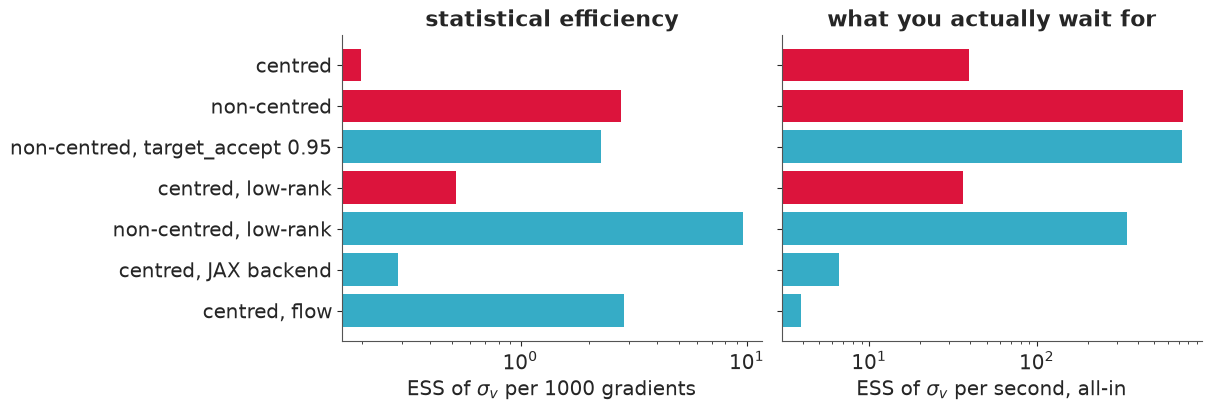

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
order = list(ladder)[::-1]
colors = ["crimson" if ladder[k]["divergences"] > 10 or ladder[k]["max r_hat"] > 1.01 else "C0" for k in order]
axes[0].barh(order, [ladder[k]["ESS/1000 grads"] for k in order], color=colors)
axes[0].set(xscale="log", xlabel="ESS of $\\sigma_v$ per 1000 gradients", title="statistical efficiency")
axes[1].barh(order, [ladder[k]["ESS/s"] for k in order], color=colors)
axes[1].set(xscale="log", xlabel="ESS of $\\sigma_v$ per second, all-in", title="what you actually wait for");

(Red bars: more than 10 divergences or `r_hat` above 1.01 - runs you would not accept.
Seconds depend on the machine and on what else it is doing; the ratios and the
per-gradient column are the robust part.)

**What the flow achieved.** On the form we could not fix by hand it is a real success: no
divergences, a clean `r_hat`, an ESS for $\sigma_v$ five times or more that of any other
centred run, at a quarter of the gradients per draw. Per *gradient* (left panel) the
flow-adapted centred model is level with the hand-written non-centred one and an order of
magnitude ahead of the plain centred one. It found, by itself, a reparameterisation about
as good as ours. Only the combination of *both* manual tricks - non-centred and low-rank -
is clearly better per gradient, by a factor of about three.

**What it cost.** Per *second* it is last, and a couple of hundred times behind the
non-centred numba runs. (It trails even the plain JAX run here only because its four chains
ran one after another to stay under 3 GB of memory, which inflates "total s"; the per-chain
columns are the fair comparison.) The cost table shows where the time went:

- *Warm-up* is nine-tenths of each chain's run. For the numba rungs it is a fraction of a
  second to a few seconds; here each chain trains a neural network several times over.
- *JAX on a CPU, for a model this small, is slow per call*: the plain JAX-backend run pays
  twenty to thirty times more per gradient than numba (`microsec/grad`). That has nothing
  to do with flows - it is dispatch overhead, and it would shrink in relative terms on a
  model with heavy linear algebra or on a GPU.
- *Each gradient through the network* costs somewhat more again - about one and a half times
  here, with one flow running at a time, and several times more when four flows compete for
  the same cores. But the flow needs only a quarter of the gradients per draw, so **once it
  is trained it samples about three times faster than the plain JAX run**. The bill is
  almost entirely the training.

The settings matter, too. In off-notebook experiments on this model, two or three layers
with 30 epochs failed to learn the funnel - about 50 gradients per draw and a dozen or
more divergences, in no less wall time, because sampling through a bad flow is slow. And
on E02's radon model nutpie's defaults took between two and three times as long as the
lighter settings used here.

**The verdict for this model:** the boring answer wins. Non-centred with
`target_accept=0.95` or with a low-rank mass matrix gives a usable posterior - a handful
of divergences, which the reference needed 0.99 to remove entirely - in a few seconds
including compilation. (Between those two, low-rank is the clear winner per gradient and
the plain run per second, because two seconds of extra warm-up matter when sampling
takes a fraction of a second. On a model with an expensive gradient that order flips.)
The flow is worth its price when the arithmetic changes: when each gradient is
expensive in its own right (an ODE solve, a large dataset), so that the training overhead
and the per-call cost are small next to needing a quarter of the gradients; or when you
cannot find a parameterisation that works at all and the alternative is no answer.

## 4 · When you cannot afford MCMC: approximations, and how to know if they lie

Suppose the model were a thousand times bigger and NUTS were off the table. The usual
substitutes fit a simple distribution $q$ to the posterior $p$:

- **Laplace**: find the posterior mode, use the curvature there as a Gaussian covariance.
- **Mean-field ADVI**: the best *independent* Gaussian (in unconstrained space) by
  stochastic optimisation of the ELBO. **Full-rank ADVI**: the best correlated Gaussian.
- **Pathfinder** (Zhang, Carpenter, Gelman & Vehtari, 2022): follow an L-BFGS optimisation
  path towards the mode, build a Gaussian from the optimiser's curvature estimate at every
  point along the path, and keep the one with the best ELBO - the idea being that the best
  Gaussian sits somewhere *before* the mode, in the region of high mass. Multi-path
  Pathfinder runs several paths from different starts and pools them, optionally with
  importance resampling.

All of these return draws, and none of them comes with an `r_hat`. We have a reference
here; in real life you would not. The diagnostic that needs no reference is the
**Pareto $\hat k$** of Yao, Vehtari, Simpson & Gelman (2018), the same statistic as in
PSIS-LOO: draw from $q$, compute the importance ratios $p(\theta)/q(\theta)$ - both densities
are available, $p$ up to a constant - and fit a generalised Pareto distribution to the
largest ratios. If $q$ covers $p$ the ratios are bounded and $\hat k$ is small. If $q$ is
too narrow or in the wrong place, a few draws in $q$'s tails carry astronomically large
ratios and $\hat k$ is large. The conventional reading: below 0.5 good, up to 0.7 usable
(and importance weighting will then *correct* the approximation), above 0.7 do not trust
it, above 1 the ratios do not even have a finite mean.

### Machinery

Every Gaussian approximation lives in the **unconstrained** space ($\log \sigma_v$,
$\log \nu$, ...). So we need the model's log-density and the map back to the natural
parameters as functions of one flat unconstrained vector - a few lines of PyTensor.
ArviZ 1 exposes PSIS through the `.azstats` accessor; note that `psislw` expects the
**negative** log-ratios (its LOO heritage: there the weights are one over the likelihood).

In [16]:
def flat_functions(model):
    """log p(theta, y) (with Jacobian) and the constrained parameters, as functions of one flat unconstrained vector."""
    point = model.initial_point()
    [logp], flat = join_nonshared_inputs(point=point, outputs=[model.logp(jacobian=True)], inputs=model.value_vars)
    logp_fn = pytensor.function([flat], logp)
    outputs, flat = join_nonshared_inputs(point=point, outputs=model.unobserved_value_vars, inputs=model.value_vars)
    constrain_fn = pytensor.function([flat], outputs)
    names = [v.name for v in model.unobserved_value_vars]

    def constrain(xs):
        cols = [constrain_fn(row) for row in xs]
        return {n: np.stack([c[j] for c in cols]) for j, n in enumerate(names)}

    return (lambda xs: np.array([logp_fn(row) for row in xs])), constrain


def psis(log_ratios):
    """Pareto k-hat and normalised smoothed importance weights for log p - log q."""
    lw, k = xr.DataArray(-log_ratios, dims=["sample"]).azstats.psislw(dim="sample")
    w = np.exp(lw.values - lw.values.max())
    return float(k), w / w.sum()


logp_nc, constrain_nc = flat_functions(noncentred_model)
print("unconstrained vector:", [(name, value.size) for name, value in noncentred_model.initial_point().items()])

approx = {}  # label -> dict(draws, khat, seconds, weights)


def gaussian_approximation(label, mean, cov, seconds, n=10_000):
    """Draw from N(mean, cov) in unconstrained space, compute k-hat against the true log-density."""
    draw_rng = np.random.default_rng(RANDOM_SEED)
    xs = draw_rng.multivariate_normal(mean, cov, size=n, method="cholesky")
    log_q = stats.multivariate_normal(mean, cov).logpdf(xs)
    khat, weights = psis(logp_nc(xs) - log_q)
    approx[label] = {"draws": constrain_nc(xs), "khat": khat, "weights": weights, "seconds": seconds}
    print(f"{label}: k-hat = {khat:.2f} ({seconds:.1f} s)")

unconstrained vector: [('vol_of_vol_log__', 1), ('nu_log__', 1), ('mu', 1), ('log_vol_0', 1), ('z', 125)]


### Fit them all

We use the **non-centred** model: its unconstrained posterior is the closer of the two to
a Gaussian, which is the kindest thing we can do for a Gaussian approximation. ADVI's
ordering of the flat vector is the model's `value_vars` order (we checked
`approx.groups[0].ordering`); `fit_laplace` returns a labelled mean vector and covariance
in its own order, which we permute.

In [17]:
tic = time.perf_counter()
with noncentred_model:
    for method, label, n_iter in [("advi", "mean-field ADVI", 30_000), ("fullrank_advi", "full-rank ADVI", 60_000)]:
        start = time.perf_counter()
        vi = pm.fit(n_iter, method=method, random_seed=RANDOM_SEED, progressbar=False)
        gaussian_approximation(label, vi.mean.eval(), vi.cov.eval(), time.perf_counter() - start)

    start = time.perf_counter()
    laplace = pmx.fit_laplace(optimize_method="BFGS", random_seed=RANDOM_SEED, progressbar=False, draws=10,
                              optimizer_kwargs={"options": {"maxiter": 300}})
    seconds = time.perf_counter() - start
    row_var = np.array([str(lbl).split("[")[0] for lbl in laplace["fit"]["rows"].values])
    perm = np.concatenate([np.flatnonzero(row_var == v.name) for v in noncentred_model.value_vars])
    gaussian_approximation("Laplace", laplace["fit"]["mean_vector"].values[perm],
                           laplace["fit"]["covariance_matrix"].values[np.ix_(perm, perm)], seconds)
section_seconds["4a ADVI + Laplace"] = time.perf_counter() - tic

Finished [100%]: Average Loss = 329.44


mean-field ADVI: k-hat = 1.25 (1.8 s)


Finished [100%]: Average Loss = 316.7


full-rank ADVI: k-hat = 0.84 (6.3 s)


Laplace: k-hat = 2.67 (0.3 s)


Pathfinder is not one Gaussian but a pool of them, so we cannot recompute its density from
a mean and a covariance; `fit_pathfinder` computes $\log p - \log q$ internally and reports
$\hat k$ when importance sampling is on. We therefore run each configuration twice: with
`importance_sampling=None` for the raw draws, and with `"psis"` for $\hat k$ and the
importance-resampled draws.

In [18]:
tic = time.perf_counter()
with noncentred_model:
    for n_paths, label in [(1, "Pathfinder, 1 path"), (8, "Pathfinder, 8 paths")]:
        start = time.perf_counter()
        raw = pmx.fit_pathfinder(num_paths=n_paths, num_draws=2000, importance_sampling=None, parallel=False,
                                 random_seed=RANDOM_SEED, progressbar=False)
        seconds = time.perf_counter() - start
        resampled = pmx.fit_pathfinder(num_paths=n_paths, num_draws=2000, importance_sampling="psis", parallel=False,
                                       random_seed=RANDOM_SEED, progressbar=False)
        khat = float(resampled["pathfinder"]["pareto_k"])
        approx[label] = {"draws": as_draws(raw), "khat": khat, "seconds": seconds, "resampled": as_draws(resampled),
                         "idata": raw}
        print(f"{label}: k-hat = {khat:.2f} ({seconds:.1f} s)")
section_seconds["4b Pathfinder"] = time.perf_counter() - tic

Pathfinder, 1 path: k-hat = 2.28 (0.7 s)


Pathfinder, 8 paths: k-hat = 3.48 (0.9 s)


One more, as a calibration point for $\hat k$ itself - and it is cheating, because it uses
the reference: the **moment-matched Gaussian**, with the mean and covariance of the
reference draws in unconstrained space. No Gaussian-fitting method can be expected to do
much better, so its $\hat k$ tells us how Gaussian this posterior is in the first place.

In [19]:
ref_unconstrained = np.column_stack([
    np.log(ref_draws["vol_of_vol"]), np.log(ref_draws["nu"]), ref_draws["mu"],
    ref_post["log_vol_0"].values.ravel(), ref_post["z"].values.reshape(-1, T),
])
gaussian_approximation("moment-matched Gaussian (oracle)", ref_unconstrained.mean(0), np.cov(ref_unconstrained.T), np.nan)

moment-matched Gaussian (oracle): k-hat = 0.77 (nan s)


In [20]:
rows = {}
for label, a in approx.items():
    rows[label] = {"k-hat": a["khat"], "seconds": a["seconds"], **accuracy(a["draws"])}
    corrected = accuracy(a["draws"], a["weights"]) if "weights" in a else accuracy(a["resampled"])
    rows[label]["sigma_v z, PSIS-corrected"] = corrected["sigma_v z"]
    rows[label]["sigma_v sd ratio, PSIS-corrected"] = corrected["sigma_v sd ratio"]
approx_table = pd.DataFrame(rows).T.sort_values("k-hat")
approx_table.round(2)

,k-hat,seconds,sigma_v mean,sigma_v z,sigma_v sd ratio,log_vol median |z|,log_vol sd ratio,"sigma_v z, PSIS-corrected","sigma_v sd ratio, PSIS-corrected"
moment-matched Gaussian (oracle),0.77,NaN,0.12,-0.02,1.02,0.01,1.25,0.14,1.17
full-rank ADVI,0.84,6.26,0.09,-0.85,0.51,0.08,1.06,-0.36,0.69
mean-field ADVI,1.25,1.79,0.04,-2.46,0.13,0.71,1.38,-2.19,0.13
"Pathfinder, 1 path",2.28,0.75,0.04,-2.40,1.58,1.52,2.24,-0.64,0.60
Laplace,2.67,0.27,0.98,24.60,5.40,1.35,3.26,10.46,0.81
"Pathfinder, 8 paths",3.48,0.92,0.04,-2.43,1.07,1.01,1.95,-2.78,0.70


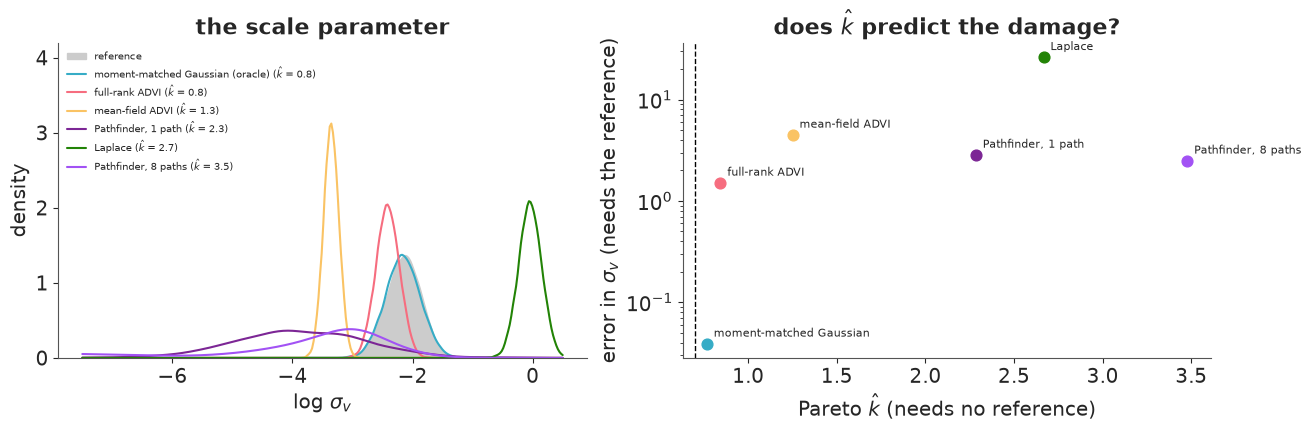

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
grid = np.linspace(-7.5, 0.5, 300)
axes[0].fill_between(grid, stats.gaussian_kde(np.log(ref_draws["vol_of_vol"]))(grid), color="0.8", label="reference")
for j, label in enumerate(approx_table.index):
    d = np.log(approx[label]["draws"]["vol_of_vol"])
    axes[0].plot(grid, stats.gaussian_kde(d)(grid), color=f"C{j}", label=f"{label} ($\\hat k$ = {approx[label]['khat']:.1f})")
axes[0].set(xlabel="log $\\sigma_v$", ylabel="density", ylim=(0, 4.2), title="the scale parameter")
axes[0].legend(fontsize=7, loc="upper left")

for j, label in enumerate(approx_table.index):
    err = abs(approx_table.loc[label, "sigma_v z"]) + abs(np.log(approx_table.loc[label, "sigma_v sd ratio"]))
    axes[1].scatter(approx_table.loc[label, "k-hat"], err, color=f"C{j}", s=60)
    axes[1].annotate(label.split(" (")[0], (approx_table.loc[label, "k-hat"], err), fontsize=8,
                     xytext=(5, 5), textcoords="offset points")
axes[1].axvline(0.7, color="k", ls="--", lw=1)
axes[1].set(yscale="log", xlabel="Pareto $\\hat k$ (needs no reference)",
            ylabel="error in $\\sigma_v$ (needs the reference)",
            title="does $\\hat k$ predict the damage?");

**Every real method gets the scale parameter wrong, and $\hat k$ says so for every one of
them** - none is below 0.7. From the bottom of the table:

- **Laplace** is not even in the right region: it puts $\sigma_v$ near 1 (the reference
  says 0.12), some 25 reference sds away. The reason is structural. In the non-centred
  form the joint density has its *maximum* where the shocks are small and $\sigma_v$ is
  large - nothing but the HalfNormal prior stops it. In the centred form it is the
  opposite: the density grows without bound as $\sigma_v \to 0$ with a flat path (we
  tried: BFGS gives up around $\sigma_v \approx 10^{-4}$). The *mode* of a hierarchical
  posterior depends on the parameterisation and says little about where the *mass* is.
- **Pathfinder** ends up somewhere else, but no better: $\sigma_v$ about a third of the
  reference mean, smeared over several orders of magnitude (left panel), and daily
  volatilities that are off by a posterior sd or more. Importance resampling is a lottery
  at these $\hat k$: it improved the single-path estimate of $\sigma_v$ and made the
  8-path one worse. That is what $\hat k > 1$ means - the weights have no finite mean, so
  a handful of draws decide the outcome.
- **Mean-field ADVI** shows the classic variational failure in its purest form:
  $\sigma_v$ two and a half reference sds too low with **an eighth of the posterior sd**.
  Minimising $\text{KL}(q\,\|\,p)$ punishes $q$ for putting mass where $p$ has none and
  never for missing mass, so a factorised $q$ facing the ridge of section 2 shrinks into
  it - and reports great certainty about a wrong value. Reweighting cannot repair it.
- **Full-rank ADVI** is the best of the real methods, with $\hat k$ just over the line:
  the mean is a little under one sd low and the sd about half what it should be, while the
  daily volatilities are nearly right. Here PSIS does roughly what it promises for a
  borderline $\hat k$: the importance-weighted estimate moves about half-way back to the
  reference in both mean and sd.
- The **oracle Gaussian** reproduces every marginal mean and sd by construction - and
  still has a $\hat k$ near the 0.7 line. That is worth knowing about $\hat k$: it judges
  the *joint* density in all 129 dimensions, where this posterior is visibly not Gaussian
  (the ridge again), and it tends to get more demanding as the dimension grows. It is also itself
  an estimate: repeating the oracle computation with other seeds for the draws we saw
  values between 0.5 and 0.8.

So what does $\hat k$ buy you? Look at the right-hand panel, whose vertical axis adds up
the two errors in $\sigma_v$ (|z of the mean| + |log of the sd ratio|). It **never gave false
reassurance**: every approximation that was wrong was flagged. Among the Gaussian
approximations its order is the order of the actual errors (oracle, full-rank,
mean-field, Laplace). But it is an alarm, not a ruler: above 1 its size says little about
the size of the damage (Pathfinder with 8 paths has the largest $\hat k$ and nothing like
the largest error), and near 0.7 it can condemn an approximation whose marginals are
fine. A small $\hat k$ is strong evidence; a large one tells you that importance sampling
cannot vouch for the approximation, and that you need another check - or MCMC.

One more pattern to take away: full-rank ADVI got the *locations* of 125 well-identified
volatilities right while missing the spread of the one hierarchical scale by half.
Approximations fail first on **scales and hierarchical variances**, which is exactly what
partial pooling, forecasts and risk numbers depend on.

### What a wrong posterior does to a decision

A risk desk wants the 10-day 99% value-at-risk on 26 December 2008: the loss over the next
ten trading days that is exceeded with probability 1%. It depends on today's volatility,
on how fast volatility can move ($\sigma_v$ - over ten days that compounds) and on the
tails ($\nu$). Simulate it forward from each posterior.

In [22]:
def var_10_day(draws, seed=RANDOM_SEED, horizon=10, level=0.99):
    sim = np.random.default_rng(seed)
    n = len(draws["vol_of_vol"])
    log_vol_path = draws["log_vol"][:, -1, None] + draws["vol_of_vol"][:, None] * sim.normal(size=(n, horizon)).cumsum(axis=1)
    daily = draws["mu"][:, None] + np.exp(log_vol_path) * sim.standard_t(draws["nu"][:, None], size=(n, horizon))
    return -np.quantile(daily.sum(axis=1), 1 - level)


def var_row(draws):
    today = np.exp(draws["log_vol"][:, -1])
    return {"10-day 99% VaR (%)": var_10_day(draws), "sigma_v mean": draws["vol_of_vol"].mean(),
            "today's vol, median (%)": np.median(today), "today's vol, 97% quantile (%)": np.quantile(today, 0.97)}


var_table = pd.DataFrame({"reference": var_row(ref_draws), **{k: var_row(approx[k]["draws"]) for k in approx_table.index}}).T
var_table["VaR relative to reference"] = var_table["10-day 99% VaR (%)"] / var_table.loc["reference", "10-day 99% VaR (%)"]
var_table.round(2)

,10-day 99% VaR (%),sigma_v mean,"today's vol, median (%)","today's vol, 97% quantile (%)",VaR relative to reference
reference,23.22,0.12,1.96,3.87,1.00
moment-matched Gaussian (oracle),23.31,0.12,2.02,3.98,1.00
full-rank ADVI,25.79,0.09,2.38,4.53,1.11
mean-field ADVI,41.48,0.04,3.27,7.74,1.79
"Pathfinder, 1 path",69.18,0.04,3.09,12.24,2.98
Laplace,645.63,0.98,0.57,2.77,27.81
"Pathfinder, 8 paths",37.09,0.04,2.88,7.55,1.60


The reference says: hold capital against a ten-day loss of just under a quarter of the
portfolio (this is December 2008). The oracle Gaussian agrees, and full-rank ADVI is about
a tenth too high. Mean-field ADVI and Pathfinder ask for **1.6 to 3 times** the capital,
and Laplace reports a loss of several times the entire portfolio.

The direction is instructive. A too-small, too-certain $\sigma_v$ should by itself *lower*
the VaR - volatility that cannot move cannot spike. But the damage surfaces somewhere
else: in the non-centred form today's log-volatility is $v_0$ plus $\sigma_v$ times the sum
of 125 shocks, so an approximation that is slightly off for every shock and badly off
for $\sigma_v$ is a long way off for the sum. The last two columns show it: mean-field ADVI
and Pathfinder put today's volatility around 3% instead of 2%, with an upper tail two to
three times too long. An error in a parameter you may not even report ends up, amplified,
in the number the desk acts on.

None of these results *looks* wrong from the inside: each method returned a full set of
draws and printed no warning. Only $\hat k$ (or a reference) tells you.

## 5 · Approximations as initialisers, and a decision guide

A common suggestion: even if Pathfinder's draws cannot be trusted, use them to **start**
NUTS close to the posterior and shorten warm-up. nutpie accepts starting values at compile
time (`initial_points=`; through PyMC it is `pm.sample(initvals=...)`). Test: the
non-centred model with `target_accept=0.95` and only **100** warm-up draws, started from
the default initial point (plus nutpie's jitter) or from the single-path Pathfinder mean.

In [23]:
tic = time.perf_counter()
pf_posterior = approx["Pathfinder, 1 path"]["idata"].posterior
initial_points = {rv.name: pf_posterior[rv.name].mean(("chain", "draw")).values for rv in noncentred_model.free_RVs}

compiled_default = nutpie.compile_pymc_model(noncentred_model)
compiled_pf = nutpie.compile_pymc_model(noncentred_model, initial_points=initial_points, jitter_rvs=set())

init_rows, warmup_logp = {}, {}
for label, compiled in [("default start", compiled_default), ("Pathfinder start", compiled_pf)]:
    for tune in [100, 1000]:
        idata = nutpie.sample(compiled, draws=1000, tune=tune, chains=4, seed=RANDOM_SEED, target_accept=0.95, progress_bar=False)
        s = az.summary(idata, var_names=["vol_of_vol"], round_to=4)
        init_rows[(label, tune)] = {
            "divergences": int(idata.sample_stats["diverging"].sum()), "ESS sigma_v": s["ess_bulk"].iloc[0],
            "r_hat": s["r_hat"].iloc[0], "sigma_v mean": s["mean"].iloc[0],
            "warm-up gradients": int(idata.warmup_sample_stats["n_steps"].sum()),
        }
        if tune == 100:
            warmup_logp[label] = idata.warmup_sample_stats["logp"].values
section_seconds["5 initialisation experiment"] = time.perf_counter() - tic

init_table = pd.DataFrame(init_rows).T
init_table.index.names = ["start", "warm-up draws"]
init_table

divergences  ESS sigma_v   r_hat  \
start            warm-up draws                                     
default start    100                    1.0    1113.3612  1.0042   
                 1000                   2.0    1240.5351  1.0032   
Pathfinder start 100                    1.0    1512.6825  1.0030   
                 1000                   0.0    1166.1799  1.0038   

                                sigma_v mean  warm-up gradients  
start            warm-up draws                                   
default start    100                  0.1226            44202.0  
                 1000                 0.1184           295217.0  
Pathfinder start 100                  0.1204            34811.0  
                 1000                 0.1223           286297.0

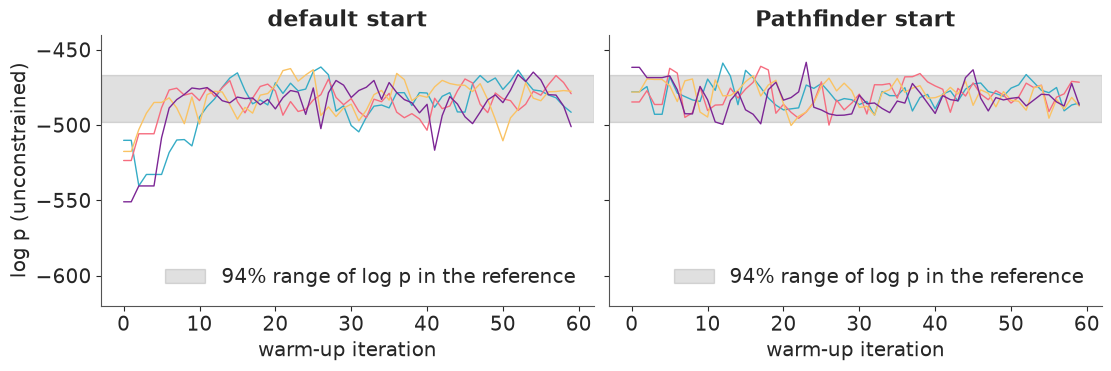

In [24]:
typical = reference.sample_stats["logp"].quantile([0.03, 0.97]).values
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (label, lp) in zip(axes, warmup_logp.items()):
    ax.plot(lp[:, :60].T, lw=1)
    ax.axhspan(*typical, color="k", alpha=0.12, label="94% range of log p in the reference")
    ax.set(title=label, xlabel="warm-up iteration", ylim=(-620, -440))
    ax.legend(loc="lower right")
axes[0].set(ylabel="log p (unconstrained)");

Pathfinder does what was asked of it: its chains sit inside the reference's typical range
of log-density from the first iteration (right), whereas from the default start NUTS
needs ten to fifteen iterations to get there (left). But those ten iterations are all
there is to save. With a 100-draw warm-up the Pathfinder start used about a fifth fewer
warm-up gradients; with the usual 1000 the difference is a few percent; and ESS and
divergences are the same within run-to-run noise either way. What takes time in warm-up
on this model is learning the step size and the mass matrix, and a starting point does
not help with that. (Note the irony: a Pathfinder fit whose *draws* were useless is a
perfectly good *starting point* - a much lower bar.) Initialisation from an approximation
pays when finding the typical set is the hard part: badly scaled models where the first
phase of warm-up takes hundreds of iterations, or multimodal ones where a bad start
means a wrong mode (E10).

### Which tool when

The measured numbers from this notebook in one table, then the advice.

In [25]:
summary_rows = {}
for label, row in ladder.items():
    summary_rows[label] = {
        "kind": "MCMC", "seconds": row["total s"], "divergences": row["divergences"], "ESS sigma_v": round(row["ESS sigma_v"]),
        "k-hat": np.nan, "sigma_v z": score.loc[label, "sigma_v z"], "sigma_v sd ratio": score.loc[label, "sigma_v sd ratio"],
    }
for label in approx_table.index:
    summary_rows[label] = {
        "kind": "approximation", "seconds": approx_table.loc[label, "seconds"], "divergences": np.nan, "ESS sigma_v": np.nan,
        "k-hat": approx_table.loc[label, "k-hat"], "sigma_v z": approx_table.loc[label, "sigma_v z"],
        "sigma_v sd ratio": approx_table.loc[label, "sigma_v sd ratio"],
    }
summary = pd.DataFrame(summary_rows).T
summary[summary.columns[1:]] = summary[summary.columns[1:]].astype(float).round(2)
summary

,kind,seconds,divergences,ESS sigma_v,k-hat,sigma_v z,sigma_v sd ratio
centred,MCMC,2.46,0.0,97.0,NaN,0.00,0.98
non-centred,MCMC,1.34,59.0,985.0,NaN,-0.01,0.95
"non-centred, target_accept 0.95",MCMC,1.71,2.0,1241.0,NaN,-0.07,0.98
"centred, low-rank",MCMC,2.65,0.0,96.0,NaN,-0.13,0.95
"non-centred, low-rank",MCMC,3.99,8.0,1368.0,NaN,-0.00,0.98
"centred, JAX backend",MCMC,22.16,0.0,147.0,NaN,0.07,1.00
"centred, flow",MCMC,191.04,0.0,747.0,NaN,0.01,1.01
moment-matched Gaussian (oracle),approximation,NaN,NaN,NaN,0.77,-0.02,1.02
full-rank ADVI,approximation,6.26,NaN,NaN,0.84,-0.85,0.51
mean-field ADVI,approximation,1.79,NaN,NaN,1.25,-2.46,0.13


| Situation | Reach for | How (`pm.sample` spelling) | What we measured here |
|---|---|---|---|
| Funnel, scale weakly identified | Non-centre (E02) | model change | centred: ESS of $\sigma_v$ around 100 of 4000, no divergence to warn you |
| Divergences remain after non-centring, posterior otherwise fine | Smaller step size, **and verify against a second parameterisation** | `target_accept=0.95` (0.99 for the reference) | divergences from dozens to a couple, for about 1.6x the gradients per draw |
| Strong *linear* correlations: random walks, GPs, regressions with collinear predictors | Low-rank mass matrix | `nuts={"adaptation": "low_rank"}` | 3-5x fewer gradients per draw on both forms and the best ESS per gradient overall (non-centred); does **not** fix a funnel (centred ESS unchanged); warm-up several times slower in wall time |
| No workable parameterisation, or gradients so expensive that warm-up overhead is irrelevant | Normalizing-flow adaptation | `nuts={"adaptation": "flow"}, compile_kwargs={"backend": "jax", "gradient_backend": "jax"}`; settings via `nutpie`'s `with_transform_adapt` | fixed the centred model automatically: as efficient per gradient as our hand-written non-centred form, but over 100x slower per second on this tiny model (warm-up was 90% of the run) |
| Large model, vectorisable, GPU available | Whole-model JAX | `backend="jax"` or `nuts_sampler="numpyro"` | on a CPU at this size the JAX backend cost roughly 20x more per gradient than numba (call overhead); NumPyro not run here |
| MCMC truly unaffordable | Full-rank ADVI or Pathfinder, **with $\hat k$** and PSIS correction; never bare Laplace / mean-field for a hierarchical scale | `pm.fit`, `pmx.fit_pathfinder` | every approximation had $\hat k > 0.7$ and misjudged $\sigma_v$; full-rank ADVI + PSIS came closest; 10-day VaR off by 10% (full-rank) to 3x (Pathfinder), absurd for Laplace |
| Warm-up dominated by finding the typical set | Pathfinder / ADVI as initialiser | `initvals=` | no gain here: NUTS found the typical set in under 20 iterations by itself |

Two habits carry over to any problem. **Build a reference once** - on a subsample, a
smaller model, or overnight - and score your fast method against it before trusting it at
scale. And when there can be no reference, **compute $\hat k$**: it costs one evaluation of
the log-density per draw.

In [26]:
section_seconds["everything else (scoring, plots, VaR)"] = (time.perf_counter() - NOTEBOOK_START) - sum(section_seconds.values())
split = pd.Series(section_seconds, name="seconds")
pd.DataFrame({"seconds": split.round(1), "share": (split / split.sum()).round(2)})

,seconds,share
1 reference + cross-check,16.7,0.06
2 plain NUTS rungs,6.4,0.02
3a low-rank rungs,7.2,0.03
3b JAX-backend rung,22.5,0.09
3c normalizing-flow rung,191.3,0.73
4a ADVI + Laplace,8.7,0.03
4b Pathfinder,3.1,0.01
5 initialisation experiment,3.2,0.01
"everything else (scoring, plots, VaR)",3.1,0.01


### Try it yourself

1. **Flow on the other form.** Run the flow adaptation on `noncentred_model` instead
   (`run_nuts(noncentred_model, ..., adaptation="flow", jax_backend=True, flow_settings=FLOW_SETTINGS)`).
   Does it remove the remaining divergences without a smaller step size? How do gradients
   per draw compare with the low-rank run? Then halve `num_layers` and `max_epochs` and
   watch `grads/draw` and the divergence count to see the sensitivity for yourself.
2. **Does $\hat k$ notice the parameterisation?** Fit mean-field and full-rank ADVI to
   `centred_model` (you need `flat_functions(centred_model)` and a version of
   `gaussian_approximation` that uses it). Which form gives the better $\hat k$ and the
   better $\sigma_v$? (When we tried it the centred form was worse on both counts, with
   $\sigma_v$ several times too *large* - can you see why a factorised Gaussian over 125
   nearly collinear $v_t$ would want a rough path?)
3. **Make the gradient expensive.** Use the full 800-day training window of C07
   (`sp500.loc[:"2011-06-30"]`) and re-run rungs 2, 3 and 5. Does the ranking change as
   the model grows? Then, if you can leave the laptop alone for a while, the flow: its
   training cost grows with the dimension too (doubling the window to 250 days roughly
   doubled it for us), so work out first what would have to be true of a model for the
   flow to win per second.

Next: put this to work in **C07** (the same model, with forecasting and back-testing), or
revisit **C10** and find out whether a low-rank mass matrix helps its Rasch model with
hundreds of player effects.